In [2]:
!pip install -q transformers datasets accelerate scikit-learn ipywidgets

In [4]:
import os
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"

import re
import numpy as np
import torch
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)
from sklearn.metrics import f1_score, accuracy_score, classification_report

In [5]:
MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 128
BATCH_TRAIN = 32
BATCH_EVAL = 64
EPOCHS = 5
LR = 2e-5
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
ISEAR_LABELS = ["anger", "disgust", "fear", "guilt", "joy", "sadness", "shame"]
NUM_LABELS = len(ISEAR_LABELS)

In [6]:
ds = load_dataset("dalopeza98/isear-cleaned-dataset")
test_split = ds["test"].train_test_split(test_size=0.5, seed=42, shuffle=True)
ds = DatasetDict({
    "train":      ds["train"],
    "validation": test_split["train"],
    "test":       test_split["test"],
})

In [7]:
def clean_text(example):
    t = example["text"]
    t = re.sub(r"http\S+", "[URL]", t)
    t = re.sub(r"\s+",     " ",     t).strip()
    return {"text": t}

ds = ds.map(clean_text)

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )

ds = ds.map(tokenize, batched=True)
ds = ds.rename_column("label", "labels")

# DistilBERT neģenerē token_type_ids
cols = ["input_ids", "attention_mask", "labels"]
if "token_type_ids" in ds["train"].column_names:
    cols.append("token_type_ids")

ds.set_format(type="torch", columns=cols)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6027 [00:00<?, ? examples/s]

Map:   0%|          | 0/753 [00:00<?, ? examples/s]

Map:   0%|          | 0/754 [00:00<?, ? examples/s]

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "micro_f1": f1_score(labels, preds, average="micro"),
    }

In [10]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_LABELS,
)
model.config.id2label = {i: name for i, name in enumerate(ISEAR_LABELS)}
model.config.label2id = {name: i for i, name in enumerate(ISEAR_LABELS)}


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
steps_per_epoch = len(ds["train"]) // BATCH_TRAIN
warmup_steps = int(steps_per_epoch * 3 * 0.1)

args = TrainingArguments(
    output_dir = "./distilbert-isear",
    num_train_epochs = EPOCHS,
    per_device_train_batch_size = BATCH_TRAIN,
    per_device_eval_batch_size = BATCH_EVAL,
    eval_strategy = "epoch",
    save_strategy = "epoch",
    logging_strategy = "epoch",
    learning_rate = LR,
    lr_scheduler_type = "cosine",
    warmup_steps = warmup_steps,
    load_best_model_at_end = True,
    metric_for_best_model = "macro_f1",
    greater_is_better = True,
)

trainer = Trainer(
    model = model,
    args = args,
    train_dataset = ds["train"],
    eval_dataset = ds["validation"],
    compute_metrics = compute_metrics,
    callbacks = [EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Micro F1
1,1.561871,1.174765,0.592297,0.588199,0.592297
2,0.952830,1.039068,0.634794,0.636140,0.634794
3,0.715687,1.001878,0.653386,0.654108,0.653386
4,0.568633,1.011154,0.654714,0.653956,0.654714
5,0.507638,1.007973,0.656042,0.655142,0.656042


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=945, training_loss=0.8613318145590484, metrics={'train_runtime': 63.5102, 'train_samples_per_second': 474.49, 'train_steps_per_second': 14.879, 'total_flos': 998065252074240.0, 'train_loss': 0.8613318145590484, 'epoch': 5.0})

In [12]:
predictions = trainer.predict(ds["test"])
preds  = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

print(f"\nAccuracy: {accuracy_score(labels, preds):.4f}")
print(f"Micro F1: {f1_score(labels, preds, average='micro'):.4f}")
print(f"Macro F1: {f1_score(labels, preds, average='macro'):.4f}")
print()
print(classification_report(labels, preds, target_names=ISEAR_LABELS))


Accuracy: 0.7056
Micro F1: 0.7056
Macro F1: 0.7000

              precision    recall  f1-score   support

       anger       0.55      0.65      0.60        98
     disgust       0.70      0.67      0.68        96
        fear       0.77      0.85      0.81       103
       guilt       0.61      0.56      0.58       106
         joy       0.90      0.91      0.91       121
     sadness       0.71      0.74      0.72       112
       shame       0.66      0.54      0.60       118

    accuracy                           0.71       754
   macro avg       0.70      0.70      0.70       754
weighted avg       0.71      0.71      0.70       754



In [14]:
trainer.save_model("./distilbert-isear-final")
tokenizer.save_pretrained("./distilbert-isear-final")
print("DistilBERT modelis saglabāts!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT modelis saglabāts!


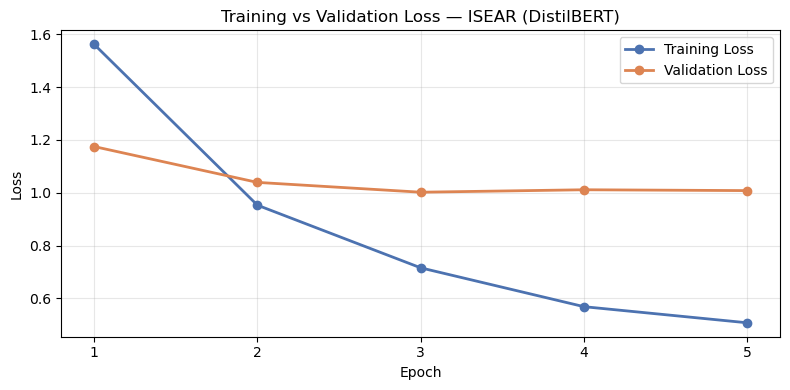

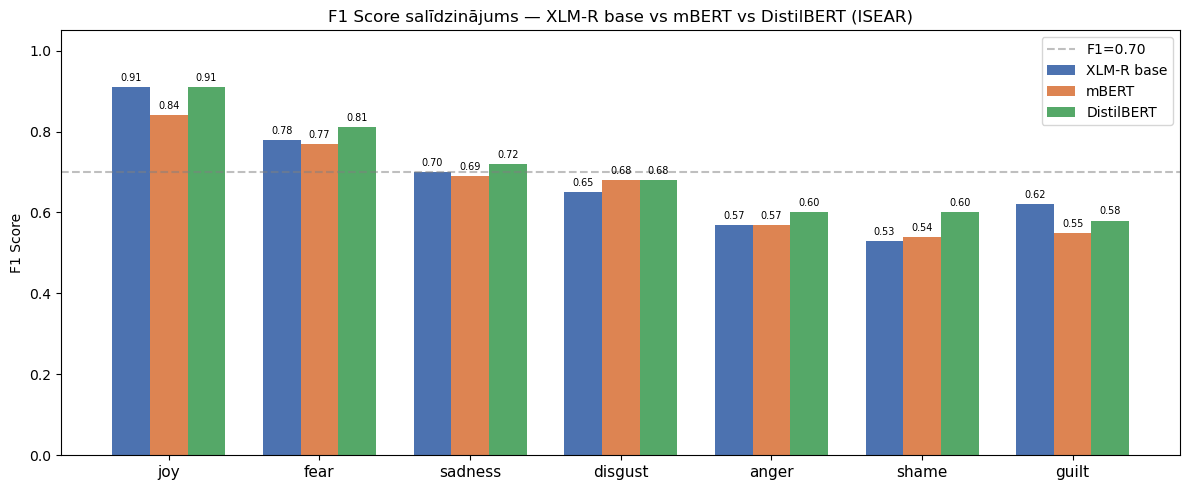

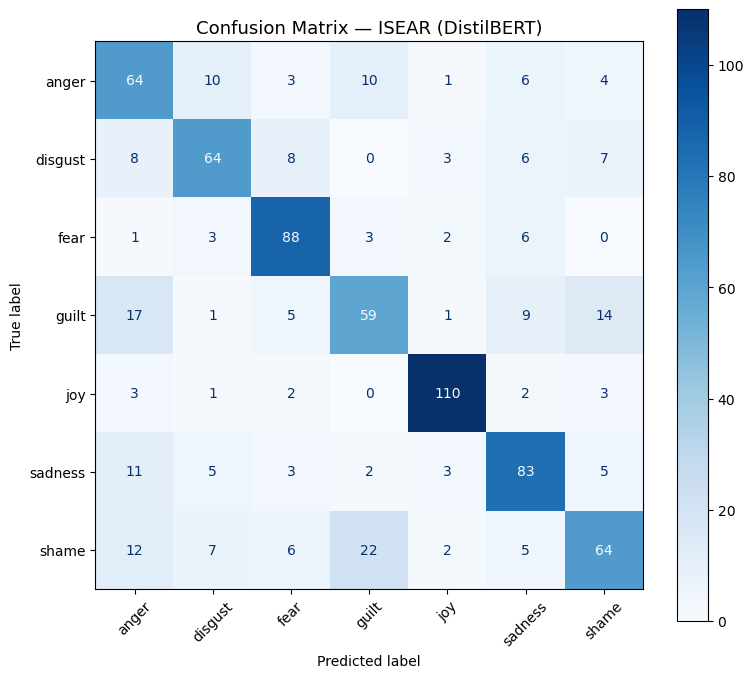


=== Modeļu salīdzinājums — ISEAR ===
Modelis           Accuracy   Micro F1   Macro F1
------------------------------------------------
DistilBERT          0.7056     0.7056     0.7000
XLM-R base          0.6857     0.6857     0.6799
mBERT               0.6618     0.6618     0.6609


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Training / Validation Loss
epochs          = [1, 2, 3, 4, 5]
training_loss   = [1.561871, 0.952830, 0.715687, 0.568633, 0.507638]
validation_loss = [1.174765, 1.039068, 1.001878, 1.011154, 1.007973]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, training_loss,   marker="o", linewidth=2, label="Training Loss",   color="#4C72B0")
ax.plot(epochs, validation_loss, marker="o", linewidth=2, label="Validation Loss", color="#DD8452")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss — ISEAR (DistilBERT)")
ax.set_xticks(epochs)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("distilbert_isear_loss.png", dpi=150)
plt.show()

# 2. F1 salīdzinājums — visi trīs modeļi
f1_xlmr = {
    "anger": 0.57, "disgust": 0.65, "fear": 0.78,
    "guilt": 0.62, "joy": 0.91, "sadness": 0.70, "shame": 0.53
}
f1_mbert = {
    "anger": 0.57, "disgust": 0.68, "fear": 0.77,
    "guilt": 0.55, "joy": 0.84, "sadness": 0.69, "shame": 0.54
}
f1_distilbert = {
    "anger": 0.60, "disgust": 0.68, "fear": 0.81,
    "guilt": 0.58, "joy": 0.91, "sadness": 0.72, "shame": 0.60
}

labels_order = sorted(f1_xlmr.keys(), key=lambda x: -f1_distilbert[x])
xlmr_vals = [f1_xlmr[l]      for l in labels_order]
mbert_vals = [f1_mbert[l]     for l in labels_order]
distilbert_vals= [f1_distilbert[l] for l in labels_order]

x = np.arange(len(labels_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
bars1 = ax.bar(x - width,   xlmr_vals,       width, label="XLM-R base", color="#4C72B0")
bars2 = ax.bar(x,           mbert_vals,      width, label="mBERT",      color="#DD8452")
bars3 = ax.bar(x + width,   distilbert_vals, width, label="DistilBERT", color="#55A868")

ax.set_xticks(x)
ax.set_xticklabels(labels_order, fontsize=11)
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score salīdzinājums — XLM-R base vs mBERT vs DistilBERT (ISEAR)", fontsize=12)
ax.set_ylim(0, 1.05)
ax.axhline(y=0.7, color="gray", linestyle="--", alpha=0.5, label="F1=0.70")
ax.legend(fontsize=10)

for bars in [bars1, bars2, bars3]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", va="bottom", fontsize=7)

plt.tight_layout()
plt.savefig("distilbert_vs_all_f1.png", dpi=150)
plt.show()

# 3. Confusion Matrix
predictions = trainer.predict(ds["test"])
preds  = np.argmax(predictions.predictions, axis=1)
labels = predictions.label_ids

cm = confusion_matrix(labels, preds)

fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=ISEAR_LABELS,
)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Confusion Matrix — ISEAR (DistilBERT)", fontsize=13)
plt.tight_layout()
plt.savefig("distilbert_isear_confusion_matrix.png", dpi=150)
plt.show()

# 4. Kopsavilkuma tabula
print("\n=== Modeļu salīdzinājums — ISEAR ===")
print(f"{'Modelis':<15} {'Accuracy':>10} {'Micro F1':>10} {'Macro F1':>10}")
print("-" * 48)
print(f"{'DistilBERT':<15} {'0.7056':>10} {'0.7056':>10} {'0.7000':>10}")
print(f"{'XLM-R base':<15} {'0.6857':>10} {'0.6857':>10} {'0.6799':>10}")
print(f"{'mBERT':<15} {'0.6618':>10} {'0.6618':>10} {'0.6609':>10}")

In [19]:
from transformers import pipeline
import time
import numpy as np
import torch

# Ielādē modeļus
classifier_distilbert = pipeline(
    "text-classification",
    model="./distilbert-isear-final",
    tokenizer="./distilbert-isear-final",
    top_k=None,
    device=0,
)
classifier_xlmr = pipeline(
    "text-classification",
    model="./xlmr-isear-final",
    tokenizer="./xlmr-isear-final",
    top_k=None,
    device=0,
)
classifier_mbert = pipeline(
    "text-classification",
    model="./mbert-isear-final",
    tokenizer="./mbert-isear-final",
    top_k=None,
    device=0,
)

# GPU atmiņas mērījums
def measure_gpu_memory(pipe, texts, batch_size=32):
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    # Palaid vienu batchu
    with torch.no_grad():
        _ = pipe(texts[:batch_size])

    torch.cuda.synchronize()
    peak_mb = torch.cuda.max_memory_allocated() / 1024**2
    curr_mb = torch.cuda.memory_allocated() / 1024**2

    print(f"  Pašreizējā GPU atmiņa: {curr_mb:.1f} MB")
    print(f"  Maksimālā GPU atmiņa:  {peak_mb:.1f} MB")
    return peak_mb

# Caurlaidības mērījums
def measure_throughput(pipe, texts, batch_size=32):
    total = len(texts)

    # Uzsildīšana
    _ = pipe(texts[:batch_size])
    torch.cuda.synchronize()

    start = time.time()
    for i in range(0, total, batch_size):
        batch = texts[i:i + batch_size]
        with torch.no_grad():
            _ = pipe(batch)
    torch.cuda.synchronize()
    elapsed = time.time() - start

    throughput = total / elapsed
    latency = (elapsed / (total / batch_size)) * 1000

    print(f"  Kopējais laiks:  {elapsed:.2f}s")
    print(f"  Caurlaidība:     {throughput:.1f} teksti/sek")
    print(f"  Latentums/batch: {latency:.1f}ms")
    return throughput

# Aiztures mērījums
def measure_latency(pipe, text, n=100):
    # Uzsildīšana
    for _ in range(10):
        _ = pipe(text)

    times = []
    for _ in range(n):
        torch.cuda.synchronize()
        start = time.perf_counter()
        _ = pipe(text)
        torch.cuda.synchronize()
        times.append(time.perf_counter() - start)

    print(f"  Vidējais:  {np.mean(times)*1000:.2f}ms")
    print(f"  Mediāna:   {np.median(times)*1000:.2f}ms")
    print(f"  P95:       {np.percentile(times, 95)*1000:.2f}ms")
    print(f"  P99:       {np.percentile(times, 99)*1000:.2f}ms")

# Parametru skaits
def count_params(pipe):
    total = sum(p.numel() for p in pipe.model.parameters())
    trainable = sum(p.numel() for p in pipe.model.parameters() if p.requires_grad)
    print(f"  Kopējie parametri:    {total:>12,}")
    print(f"  Apmācāmie parametri: {trainable:>12,}")

# Palaid visus mērījumus
test_texts  = ["This makes me so angry!"] * 1000
single_text = "This makes me so angry!"

results = {}
for name, pipe in [
    ("DistilBERT", classifier_distilbert),
    ("XLM-R base", classifier_xlmr),
    ("mBERT", classifier_mbert),
]:
    print(f"\n{'═'*45}")
    print(f"  {name}")
    print(f"{'═'*45}")

    print(f"\n--- Parametri ---")
    count_params(pipe)

    print(f"\n--- GPU atmiņa ---")
    peak_mb = measure_gpu_memory(pipe, test_texts)

    print(f"\n--- Caurlaidība ---")
    tp = measure_throughput(pipe, test_texts)

    print(f"\n--- Latentums (viens teksts) ---")
    measure_latency(pipe, single_text)

    results[name] = {"throughput": tp, "gpu_mb": peak_mb}

# Kopsavilkuma tabula
print(f"\n{'═'*55}")
print(f"  Kopsavilkums")
print(f"{'═'*55}")
print(f"{'Modelis':<15} {'Caurlaidība':>15} {'GPU atmiņa':>12}")
print(f"{'-'*45}")
for name, r in results.items():
    print(f"{name:<15} {r['throughput']:>12.1f} t/s {r['gpu_mb']:>9.1f} MB")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


═════════════════════════════════════════════
  DistilBERT
═════════════════════════════════════════════

--- Parametri ---
  Kopējie parametri:      66,958,855
  Apmācāmie parametri:   66,958,855

--- GPU atmiņa ---
  Pašreizējā GPU atmiņa: 2821.5 MB
  Maksimālā GPU atmiņa:  2821.7 MB

--- Caurlaidība ---
  Kopējais laiks:  2.31s
  Caurlaidība:     432.3 teksti/sek
  Latentums/batch: 74.0ms

--- Latentums (viens teksts) ---
  Vidējais:  2.20ms
  Mediāna:   2.05ms
  P95:       2.69ms
  P99:       4.73ms

═════════════════════════════════════════════
  XLM-R base
═════════════════════════════════════════════

--- Parametri ---
  Kopējie parametri:     278,049,031
  Apmācāmie parametri:  278,049,031

--- GPU atmiņa ---
  Pašreizējā GPU atmiņa: 2821.5 MB
  Maksimālā GPU atmiņa:  2821.7 MB

--- Caurlaidība ---
  Kopējais laiks:  4.06s
  Caurlaidība:     246.1 teksti/sek
  Latentums/batch: 130.0ms

--- Latentums (viens teksts) ---
  Vidējais:  4.05ms
  Mediāna:   3.81ms
  P95:       5.33ms